# Stage 10 — SHAP Explainability

## 1. Objective

The objective of Stage 10 is to introduce Explainable Artificial Intelligence (XAI) into the proposed imbalanced tabular classification framework.

SHAP (SHapley Additive exPlanations) is used to investigate how individual transformed features contribute to the predictions of the Logistic Regression model.

The main research question is:

> Which features contribute most strongly to the model's predictions, and how do those features influence individual predictions?

---

## 2. Dataset

The experiment uses the UCI Bank Marketing dataset:

`bank-full.csv`

The target variable is:

`y`

where:

- `0` represents no term-deposit subscription
- `1` represents term-deposit subscription

The dataset contains 45,211 observations and 17 columns.

---

## 3. Model

Logistic Regression is used as the primary model for this explainability experiment.

The model uses:

- StandardScaler for numerical features
- OneHotEncoder for categorical features
- `class_weight="balanced"`

The class-weighting strategy is consistent with the project's focus on imbalanced classification.

---

## 4. Preprocessing

Numerical variables are standardized using StandardScaler.

Categorical variables are transformed using OneHotEncoder with:

`handle_unknown="ignore"`

The preprocessing pipeline is fitted only on the training data.

The fitted preprocessing transformation is then applied to the test data.

---

## 5. SHAP Method

SHAP values quantify the contribution of individual features to model predictions.

For this Logistic Regression model, `shap.LinearExplainer` is used.

The SHAP analysis is performed on the transformed feature representation produced by the preprocessing pipeline.

Therefore, categorical variables are represented through their corresponding one-hot encoded categories.

---

## 6. Global Explainability

Global SHAP analysis calculates the mean absolute SHAP value of each transformed feature.

The mean absolute SHAP value represents the average magnitude of a feature's contribution to model predictions.

Features with larger mean absolute SHAP values have larger average influence on the model's predictions.

The global analysis includes:

- SHAP feature importance ranking
- SHAP importance percentage
- SHAP beeswarm visualization

---

## 7. Local Explainability

A single test observation is selected for local explanation.

The model's:

- predicted probability
- predicted class
- actual class
- classification threshold

are recorded.

A SHAP waterfall plot is then used to identify which features push the prediction toward or away from the positive class.

This provides an example of how the model reaches an individual prediction.

---

## 8. Interpretation of SHAP Direction

A positive SHAP contribution indicates that the feature pushes the model prediction toward the positive class.

A negative SHAP contribution indicates that the feature pushes the model prediction toward the negative class.

The magnitude of the SHAP value indicates the strength of the contribution relative to the model's prediction baseline.

---

## 9. Important Interpretation Limitation

SHAP explains the behavior of the trained machine-learning model.

It does not establish causal relationships.

Therefore, a feature with a large SHAP value should not automatically be interpreted as a causal reason why a customer subscribes to a term deposit.

The results describe model behavior rather than causal effects.

---

## 10. Relationship to the Research Framework

The explainability component complements the optimization components of the proposed framework.

The framework investigates:

1. Imbalanced classification
2. Hyperparameter optimization
3. Multi-objective optimization
4. Threshold optimization
5. Robustness analysis
6. Explainability

SHAP provides interpretability after model training and evaluation.

---

## 11. Leakage Considerations

The model is trained using only the training portion of the dataset.

The test set is kept separate during model fitting.

The preprocessing transformation is fitted using training data before being applied to the test observations.

SHAP explanations are generated after the model has been fitted.

---

## 12. Global vs Local Explainability

### Global explanation

Answers:

> Which features generally influence model predictions?

The primary output is the global SHAP importance ranking.

### Local explanation

Answers:

> Why did the model make this particular prediction?

The primary output is the SHAP waterfall explanation for an individual observation.

Both levels are necessary for a meaningful XAI analysis.

---

## 13. Saved Outputs

The following files are generated:

`../results/shap/global_shap_importance.csv`

Contains global SHAP feature importance.

`../results/shap/local_shap_explanation.csv`

Contains feature-level SHAP contributions for the selected customer.

`../results/shap/transformed_feature_names.csv`

Contains the transformed feature names used by the model.

`../results/shap/local_customer_prediction.csv`

Contains the selected customer's original features and model prediction.

`../results/metrics/xai_model_metrics.csv`

Contains the evaluation metrics of the explainability model.

---

## 14. Research Interpretation

The final paper should report the actual SHAP results obtained from the experiment.

The analysis should identify:

- Features with the largest mean absolute SHAP values
- Features that generally push predictions toward subscription
- Features that generally push predictions toward non-subscription
- Examples of individual customer-level explanations

The ranking should be reported from the experimental output and should not be assumed beforehand.

---

## 15. Relationship to Stage 11

Stage 10 establishes the initial SHAP explanations.

Stage 11 will investigate explanation stability.

The next research question is:

> Do important features and SHAP contributions remain reasonably consistent across different model runs or validation configurations?

This distinction is important because an explanation that changes substantially between runs may be less reliable for interpretation.

---

## 16. Stage 10 Conclusion

Stage 10 integrates SHAP-based global and local explainability into the proposed imbalanced tabular classification framework.

The experiment provides model-level feature importance and individual prediction explanations while maintaining a clear distinction between model explanation and causal interpretation.

In [15]:
# ============================================================
# CELL 1 — INSTALL REQUIRED PACKAGES
# ============================================================

%pip install -U shap scikit-learn pandas numpy plotly


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.5.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Note: you may need to restart the kernel to use updated packages.


In [16]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import shap

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)

print("Libraries imported successfully.")

print("SHAP version:", shap.__version__)

Libraries imported successfully.
SHAP version: 0.52.0


In [17]:
# ============================================================
# CELL 3 — LOAD DATASET
# ============================================================

data_path = "../data/raw/bank-full.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no
1,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes
2,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
3,18,student,single,unknown,no,35,no,no,telephone,21,aug,104,2,-1,0,unknown,no
4,18,student,single,secondary,no,5,no,no,cellular,24,aug,143,2,-1,0,unknown,no


In [18]:
# ============================================================
# CELL 4 — SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["y"])

y = df["y"].map({
    "no": 0,
    "yes": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

Feature shape: (45211, 16)
Target shape: (45211,)

Target distribution:


y
0    39922
1     5289
Name: count, dtype: int64

In [19]:
# ============================================================
# CELL 5 — IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ============================================================

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_columns)

print("\nCategorical features:")
print(categorical_columns)

print("\nNumeric feature count:", len(numeric_columns))
print("Categorical feature count:", len(categorical_columns))

Numeric features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numeric feature count: 7
Categorical feature count: 9


In [20]:
# ============================================================
# CELL 6 — TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
display(y_train.value_counts())

print("\nTesting target distribution:")
display(y_test.value_counts())

Training samples: 36168
Testing samples: 9043

Training target distribution:


y
0    31937
1     4231
Name: count, dtype: int64


Testing target distribution:


y
0    7985
1    1058
Name: count, dtype: int64

In [21]:
# ============================================================
# CELL 7 — CREATE PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [22]:
# ============================================================
# CELL 8 — CREATE EXPLAINABILITY MODEL
# ============================================================

xai_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Explainability model created.")

Explainability model created.


In [23]:
# ============================================================
# CELL 9 — TRAIN MODEL
# ============================================================

xai_model.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [24]:
# ============================================================
# CELL 10 — EVALUATE EXPLAINABILITY MODEL
# ============================================================

test_probabilities = xai_model.predict_proba(
    X_test
)[:, 1]

test_predictions = (
    test_probabilities >= 0.50
).astype(int)

xai_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        test_predictions
    ),
    "Precision": precision_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "Balanced_Accuracy": balanced_accuracy_score(
        y_test,
        test_predictions
    ),
    "PR_AUC": average_precision_score(
        y_test,
        test_probabilities
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        test_probabilities
    )
}

xai_metrics_df = pd.DataFrame(
    [xai_metrics]
)

display(
    xai_metrics_df.round(4)
)

,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,0.8453,0.4196,0.8412,0.5599,0.8435,0.5529,0.915


In [25]:
# ============================================================
# CELL 11 — EXTRACT FITTED PREPROCESSOR
# ============================================================

fitted_preprocessor = (
    xai_model
    .named_steps["preprocessor"]
)

classifier = (
    xai_model
    .named_steps["classifier"]
)

print("Fitted preprocessor extracted.")
print("Classifier extracted.")

Fitted preprocessor extracted.
Classifier extracted.


In [26]:
# ============================================================
# CELL 12 — TRANSFORM TEST DATA
# ============================================================

X_test_transformed = fitted_preprocessor.transform(
    X_test
)

print(
    "Transformed test shape:",
    X_test_transformed.shape
)

Transformed test shape: (9043, 51)


In [27]:
# ============================================================
# CELL 13 — GET TRANSFORMED FEATURE NAMES
# ============================================================

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(feature_names)
)

print("\nFirst 30 transformed features:")

for feature in feature_names[:30]:
    print(feature)

Number of transformed features: 51

First 30 transformed features:
numeric__age
numeric__balance
numeric__day
numeric__duration
numeric__campaign
numeric__pdays
numeric__previous
categorical__job_admin.
categorical__job_blue-collar
categorical__job_entrepreneur
categorical__job_housemaid
categorical__job_management
categorical__job_retired
categorical__job_self-employed
categorical__job_services
categorical__job_student
categorical__job_technician
categorical__job_unemployed
categorical__job_unknown
categorical__marital_divorced
categorical__marital_married
categorical__marital_single
categorical__education_primary
categorical__education_secondary
categorical__education_tertiary
categorical__education_unknown
categorical__default_no
categorical__default_yes
categorical__housing_no
categorical__housing_yes


In [28]:
# ============================================================
# CELL 14 — CREATE TRANSFORMED DATAFRAME
# ============================================================

if hasattr(
    X_test_transformed,
    "toarray"
):
    
    X_test_dense = (
        X_test_transformed
        .toarray()
    )

else:
    
    X_test_dense = (
        X_test_transformed
    )

X_test_transformed_df = pd.DataFrame(
    X_test_dense,
    columns=feature_names,
    index=X_test.index
)

print(
    "Transformed DataFrame shape:",
    X_test_transformed_df.shape
)

display(
    X_test_transformed_df.head()
)

Transformed DataFrame shape: (9043, 51)


,numeric__age,numeric__balance,numeric__day,numeric__duration,numeric__campaign,numeric__pdays,numeric__previous,categorical__job_admin.,categorical__job_blue-collar,categorical__job_entrepreneur,...,categorical__month_jun,categorical__month_mar,categorical__month_may,categorical__month_nov,categorical__month_oct,categorical__month_sep,categorical__poutcome_failure,categorical__poutcome_other,categorical__poutcome_success,categorical__poutcome_unknown
1708,-1.407240,0.446041,1.465803,0.036097,-0.567729,-0.411234,-0.241666,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8528,-0.936289,-0.429733,0.144116,0.320575,-0.245092,-0.411234,-0.241666,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
13353,-0.653719,-0.541911,1.225496,-0.228896,-0.567729,-0.411234,-0.241666,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6369,-1.030479,-0.392997,1.706110,0.242636,-0.245092,-0.411234,-0.241666,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
31905,0.476563,1.517962,1.105343,-0.415949,-0.567729,1.432345,0.589858,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [29]:
# ============================================================
# CELL 15 — CREATE SHAP LINEAR EXPLAINER
# ============================================================

explainer = shap.LinearExplainer(
    classifier,
    X_test_transformed_df
)

print("SHAP LinearExplainer created successfully.")

Background dataset has 9043 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=9043 when initializing the masker.


SHAP LinearExplainer created successfully.


In [30]:
# ============================================================
# CELL 16 — CALCULATE SHAP VALUES
# ============================================================

shap_values = explainer(
    X_test_transformed_df
)

print("SHAP values calculated successfully.")

print(
    "SHAP value shape:",
    shap_values.values.shape
)

SHAP values calculated successfully.
SHAP value shape: (9043, 51)


In [31]:
# ============================================================
# CELL 17 — VALIDATE SHAP OUTPUT
# ============================================================

print("=" * 80)
print("SHAP VALIDATION")
print("=" * 80)

assert shap_values.values.shape == (
    X_test_transformed_df.shape[0],
    X_test_transformed_df.shape[1]
)

assert len(feature_names) == (
    X_test_transformed_df.shape[1]
)

assert np.isfinite(
    shap_values.values
).all()

print("✓ SHAP dimensions are valid.")
print("✓ Feature names match transformed features.")
print("✓ SHAP values contain no NaN or infinite values.")

SHAP VALIDATION
✓ SHAP dimensions are valid.
✓ Feature names match transformed features.
✓ SHAP values contain no NaN or infinite values.


In [32]:
# ============================================================
# CELL 18 — GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

mean_absolute_shap = np.abs(
    shap_values.values
).mean(axis=0)

global_shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_absolute_shap
})

global_shap_importance = (
    global_shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 80)

display(
    global_shap_importance.head(20).round(5)
)

GLOBAL SHAP FEATURE IMPORTANCE


,Feature,Mean_Absolute_SHAP
0,numeric__duration,1.01687
1,categorical__contact_unknown,0.43756
2,categorical__month_may,0.28483
3,categorical__month_jul,0.28470
4,categorical__contact_cellular,0.25179
5,categorical__poutcome_unknown,0.23051
6,categorical__month_aug,0.21394
7,categorical__housing_yes,0.19806
8,categorical__housing_no,0.19195
9,numeric__campaign,0.18267


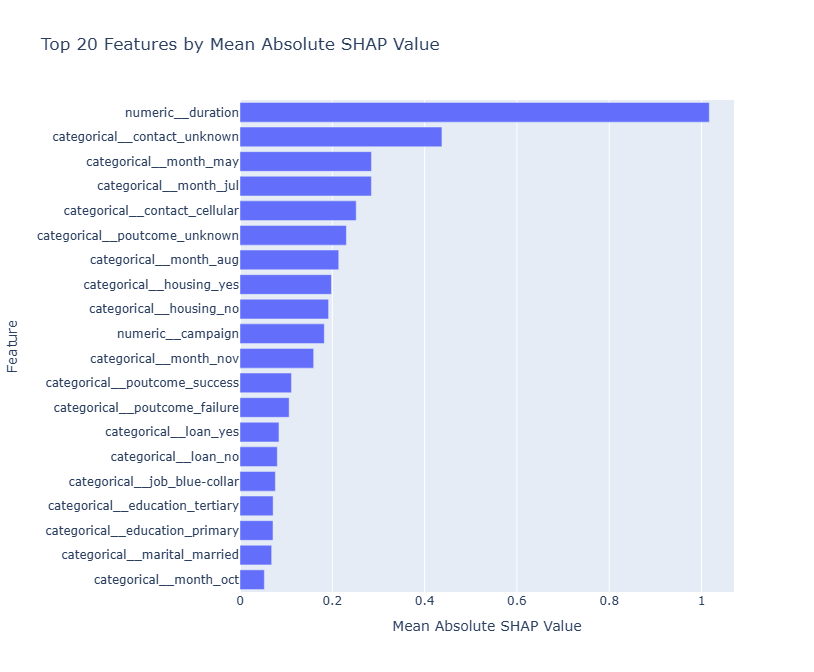

In [33]:
# ============================================================
# CELL 19 — GLOBAL SHAP IMPORTANCE PLOT
# ============================================================

top_features = (
    global_shap_importance
    .head(20)
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=True
    )
)

fig = px.bar(
    top_features,
    x="Mean_Absolute_SHAP",
    y="Feature",
    orientation="h",
    title="Top 20 Features by Mean Absolute SHAP Value",
    labels={
        "Mean_Absolute_SHAP":
            "Mean Absolute SHAP Value",
        "Feature":
            "Feature"
    },
    hover_data={
        "Mean_Absolute_SHAP": ":.5f"
    }
)

fig.update_layout(
    width=900,
    height=650
)

fig.show()

In [34]:
# ============================================================
# CELL 20 — SHAP IMPORTANCE PERCENTAGE
# ============================================================

total_shap_importance = (
    global_shap_importance[
        "Mean_Absolute_SHAP"
    ].sum()
)

global_shap_importance[
    "Importance_Percentage"
] = (
    global_shap_importance[
        "Mean_Absolute_SHAP"
    ]
    /
    total_shap_importance
    * 100
)

print("=" * 80)
print("TOP FEATURES WITH SHAP IMPORTANCE PERCENTAGE")
print("=" * 80)

display(
    global_shap_importance
    .head(20)
    .round(4)
)

TOP FEATURES WITH SHAP IMPORTANCE PERCENTAGE


,Feature,Mean_Absolute_SHAP,Importance_Percentage
0,numeric__duration,1.0169,21.2333
1,categorical__contact_unknown,0.4376,9.1367
2,categorical__month_may,0.2848,5.9475
3,categorical__month_jul,0.2847,5.9448
4,categorical__contact_cellular,0.2518,5.2577
5,categorical__poutcome_unknown,0.2305,4.8133
6,categorical__month_aug,0.2139,4.4673
7,categorical__housing_yes,0.1981,4.1357
8,categorical__housing_no,0.1919,4.0081
9,numeric__campaign,0.1827,3.8143


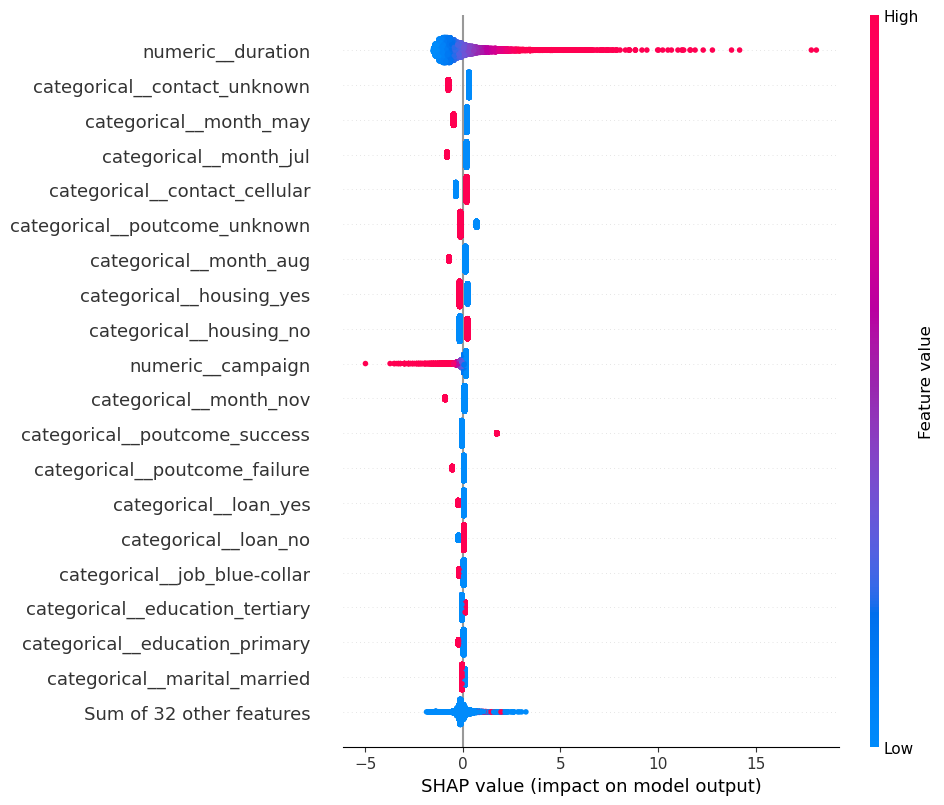

In [35]:
# ============================================================
# CELL 21 — SHAP BEESWARM PLOT
# ============================================================

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=True
)

In [36]:
# ============================================================
# CELL 22 — SELECT LOCAL EXPLANATION SAMPLE
# ============================================================

local_position = 0

local_index = X_test.index[
    local_position
]

print(
    "Selected original dataset index:",
    local_index
)

print("\nOriginal customer record:")

display(
    X_test.loc[
        [local_index]
    ]
)

Selected original dataset index: 1708

Original customer record:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
1708,26,management,single,tertiary,no,2725,no,no,cellular,28,jan,267,1,-1,0,unknown


In [37]:
# ============================================================
# CELL 23 — LOCAL PREDICTION
# ============================================================

local_probability = test_probabilities[
    local_position
]

local_prediction = int(
    local_probability >= 0.50
)

actual_label = int(
    y_test.loc[local_index]
)

print("=" * 80)
print("LOCAL CUSTOMER PREDICTION")
print("=" * 80)

print(
    f"Predicted probability of subscription: "
    f"{local_probability:.4f}"
)

print(
    f"Predicted class: {local_prediction}"
)

print(
    f"Actual class: {actual_label}"
)

print(
    f"Classification threshold: 0.50"
)

LOCAL CUSTOMER PREDICTION
Predicted probability of subscription: 0.4265
Predicted class: 0
Actual class: 0
Classification threshold: 0.50


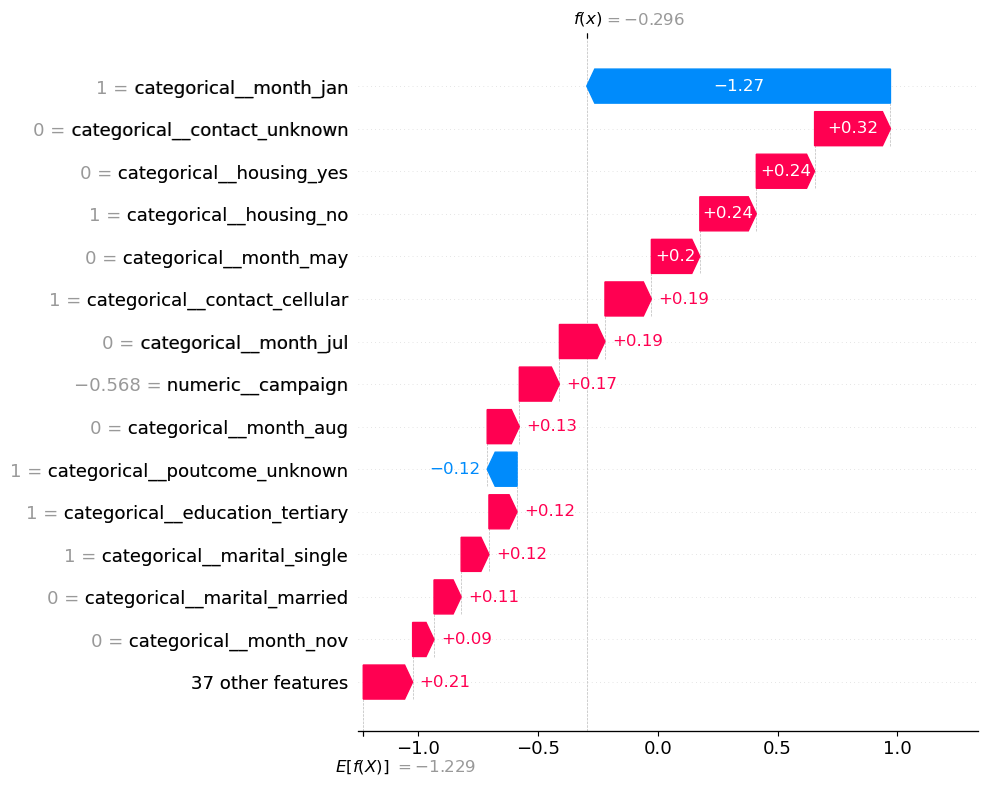

In [38]:
# ============================================================
# CELL 24 — LOCAL SHAP WATERFALL
# ============================================================

local_explanation = shap_values[
    local_position
]

shap.plots.waterfall(
    local_explanation,
    max_display=15,
    show=True
)

In [39]:
# ============================================================
# CELL 25 — LOCAL SHAP EXPLANATION TABLE
# ============================================================

local_shap_table = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": shap_values.values[
        local_position
    ]
})

local_shap_table[
    "Absolute_SHAP"
] = np.abs(
    local_shap_table["SHAP_Value"]
)

local_shap_table[
    "Direction"
] = np.where(
    local_shap_table["SHAP_Value"] >= 0,
    "Supports subscription",
    "Supports non-subscription"
)

local_shap_table = (
    local_shap_table
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("LOCAL SHAP EXPLANATION")
print("=" * 80)

display(
    local_shap_table
    .head(15)
    .round(5)
)

LOCAL SHAP EXPLANATION


,Feature,SHAP_Value,Absolute_SHAP,Direction
0,categorical__month_jan,-1.26707,1.26707,Supports non-subscription
1,categorical__contact_unknown,0.31654,0.31654,Supports subscription
2,categorical__housing_yes,0.24316,0.24316,Supports subscription
3,categorical__housing_no,0.23566,0.23566,Supports subscription
4,categorical__month_may,0.20217,0.20217,Supports subscription
5,categorical__contact_cellular,0.19363,0.19363,Supports subscription
6,categorical__month_jul,0.19015,0.19015,Supports subscription
7,numeric__campaign,0.16724,0.16724,Supports subscription
8,categorical__month_aug,0.13401,0.13401,Supports subscription
9,categorical__poutcome_unknown,-0.12471,0.12471,Supports non-subscription


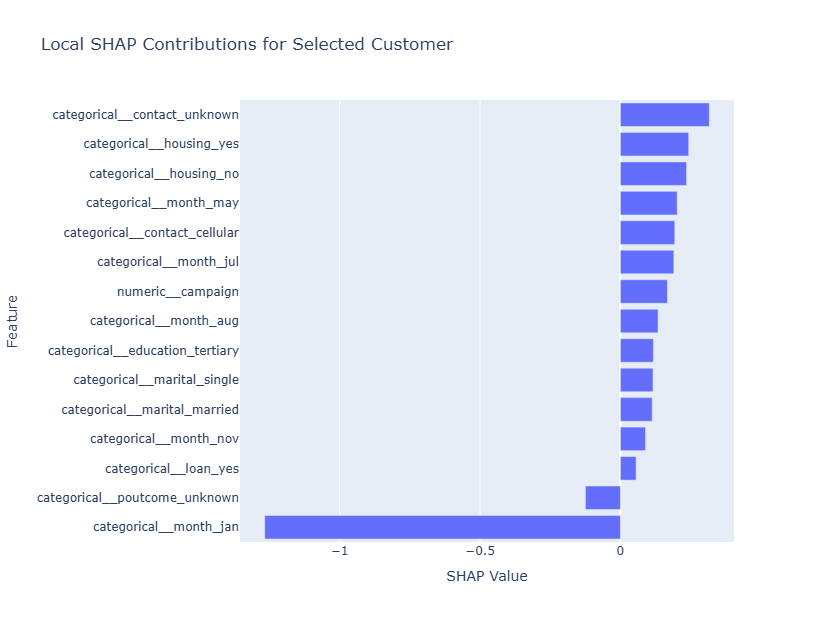

In [40]:
# ============================================================
# CELL 26 — LOCAL SHAP CONTRIBUTIONS
# ============================================================

local_plot_data = (
    local_shap_table
    .head(15)
    .sort_values(
        "SHAP_Value"
    )
)

fig = px.bar(
    local_plot_data,
    x="SHAP_Value",
    y="Feature",
    orientation="h",
    title="Local SHAP Contributions for Selected Customer",
    labels={
        "SHAP_Value": "SHAP Value",
        "Feature": "Feature"
    },
    hover_data=[
        "Absolute_SHAP",
        "Direction"
    ]
)

fig.update_layout(
    width=900,
    height=600
)

fig.show()

In [41]:
# ============================================================
# CELL 27 — GLOBAL SHAP DIRECTION
# ============================================================

mean_signed_shap = (
    shap_values.values
    .mean(axis=0)
)

global_shap_direction = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": mean_signed_shap
})

global_shap_direction[
    "Absolute_Mean_SHAP"
] = np.abs(
    global_shap_direction[
        "Mean_SHAP"
    ]
)

global_shap_direction = (
    global_shap_direction
    .sort_values(
        "Absolute_Mean_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("GLOBAL SHAP DIRECTION")
print("=" * 80)

display(
    global_shap_direction
    .head(20)
    .round(5)
)

GLOBAL SHAP DIRECTION


,Feature,Mean_SHAP,Absolute_Mean_SHAP
0,categorical__month_jul,0.03765,0.03765
1,categorical__poutcome_unknown,0.02644,0.02644
2,categorical__month_jan,-0.02499,0.02499
3,categorical__marital_married,0.02037,0.02037
4,numeric__campaign,-0.02005,0.02005
5,categorical__housing_yes,0.01765,0.01765
6,categorical__housing_no,0.01710,0.01710
7,categorical__month_aug,0.01648,0.01648
8,categorical__marital_single,0.01483,0.01483
9,categorical__month_oct,-0.01424,0.01424


In [42]:
# ============================================================
# CELL 27 — GLOBAL SHAP DIRECTION
# ============================================================

mean_signed_shap = (
    shap_values.values
    .mean(axis=0)
)

global_shap_direction = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": mean_signed_shap
})

global_shap_direction[
    "Absolute_Mean_SHAP"
] = np.abs(
    global_shap_direction[
        "Mean_SHAP"
    ]
)

global_shap_direction = (
    global_shap_direction
    .sort_values(
        "Absolute_Mean_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("GLOBAL SHAP DIRECTION")
print("=" * 80)

display(
    global_shap_direction
    .head(20)
    .round(5)
)

GLOBAL SHAP DIRECTION


,Feature,Mean_SHAP,Absolute_Mean_SHAP
0,categorical__month_jul,0.03765,0.03765
1,categorical__poutcome_unknown,0.02644,0.02644
2,categorical__month_jan,-0.02499,0.02499
3,categorical__marital_married,0.02037,0.02037
4,numeric__campaign,-0.02005,0.02005
5,categorical__housing_yes,0.01765,0.01765
6,categorical__housing_no,0.01710,0.01710
7,categorical__month_aug,0.01648,0.01648
8,categorical__marital_single,0.01483,0.01483
9,categorical__month_oct,-0.01424,0.01424


In [43]:
# ============================================================
# CELL 28 — TOP POSITIVE SHAP CONTRIBUTORS
# ============================================================

positive_features = (
    global_shap_direction
    .sort_values(
        "Mean_SHAP",
        ascending=False
    )
    .head(15)
)

print("=" * 80)
print("TOP POSITIVE SHAP CONTRIBUTORS")
print("=" * 80)

display(
    positive_features.round(5)
)

TOP POSITIVE SHAP CONTRIBUTORS


,Feature,Mean_SHAP,Absolute_Mean_SHAP
0,categorical__month_jul,0.03765,0.03765
1,categorical__poutcome_unknown,0.02644,0.02644
3,categorical__marital_married,0.02037,0.02037
5,categorical__housing_yes,0.01765,0.01765
6,categorical__housing_no,0.01710,0.01710
7,categorical__month_aug,0.01648,0.01648
8,categorical__marital_single,0.01483,0.01483
10,categorical__contact_unknown,0.01399,0.01399
12,categorical__loan_yes,0.00959,0.00959
13,categorical__loan_no,0.00918,0.00918


In [44]:
# ============================================================
# CELL 29 — TOP NEGATIVE SHAP CONTRIBUTORS
# ============================================================

negative_features = (
    global_shap_direction
    .sort_values(
        "Mean_SHAP",
        ascending=True
    )
    .head(15)
)

print("=" * 80)
print("TOP NEGATIVE SHAP CONTRIBUTORS")
print("=" * 80)

display(
    negative_features.round(5)
)

TOP NEGATIVE SHAP CONTRIBUTORS


,Feature,Mean_SHAP,Absolute_Mean_SHAP
2,categorical__month_jan,-0.02499,0.02499
4,numeric__campaign,-0.02005,0.02005
9,categorical__month_oct,-0.01424,0.01424
11,categorical__poutcome_failure,-0.01088,0.01088
20,categorical__month_may,-0.00448,0.00448
21,categorical__job_blue-collar,-0.00401,0.00401
23,categorical__month_dec,-0.00360,0.00360
24,categorical__poutcome_other,-0.00356,0.00356
26,numeric__duration,-0.00299,0.00299
27,categorical__education_unknown,-0.00295,0.00295


In [45]:
# ============================================================
# CELL 30 — SAVE GLOBAL SHAP IMPORTANCE
# ============================================================

os.makedirs(
    "../results/shap",
    exist_ok=True
)

global_shap_path = (
    "../results/shap/"
    "global_shap_importance.csv"
)

global_shap_importance.to_csv(
    global_shap_path,
    index=False
)

print(
    "Global SHAP importance saved:"
)

print(global_shap_path)

Global SHAP importance saved:
../results/shap/global_shap_importance.csv


In [46]:
# ============================================================
# CELL 31 — SAVE LOCAL SHAP EXPLANATION
# ============================================================

local_shap_path = (
    "../results/shap/"
    "local_shap_explanation.csv"
)

local_shap_table.to_csv(
    local_shap_path,
    index=False
)

print(
    "Local SHAP explanation saved:"
)

print(local_shap_path)

Local SHAP explanation saved:
../results/shap/local_shap_explanation.csv


In [47]:
# ============================================================
# CELL 32 — SAVE XAI MODEL METRICS
# ============================================================

xai_metrics_path = (
    "../results/metrics/"
    "xai_model_metrics.csv"
)

xai_metrics_df.to_csv(
    xai_metrics_path,
    index=False
)

print(
    "XAI model metrics saved:"
)

print(xai_metrics_path)

XAI model metrics saved:
../results/metrics/xai_model_metrics.csv


In [48]:
# ============================================================
# CELL 33 — SAVE TRANSFORMED FEATURE NAMES
# ============================================================

feature_names_df = pd.DataFrame({
    "Feature": feature_names
})

feature_names_path = (
    "../results/shap/"
    "transformed_feature_names.csv"
)

feature_names_df.to_csv(
    feature_names_path,
    index=False
)

print(
    "Transformed feature names saved:"
)

print(feature_names_path)

Transformed feature names saved:
../results/shap/transformed_feature_names.csv


In [49]:
# ============================================================
# CELL 34 — SAVE LOCAL CUSTOMER PREDICTION
# ============================================================

local_prediction_record = X_test.loc[
    [local_index]
].copy()

local_prediction_record[
    "Actual_Class"
] = actual_label

local_prediction_record[
    "Predicted_Class"
] = local_prediction

local_prediction_record[
    "Predicted_Probability"
] = local_probability

local_prediction_record[
    "Threshold"
] = 0.50

local_prediction_path = (
    "../results/shap/"
    "local_customer_prediction.csv"
)

local_prediction_record.to_csv(
    local_prediction_path,
    index=False
)

print(
    "Local customer prediction saved:"
)

print(local_prediction_path)

display(
    local_prediction_record
)

Local customer prediction saved:
../results/shap/local_customer_prediction.csv


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Actual_Class,Predicted_Class,Predicted_Probability,Threshold
1708,26,management,single,tertiary,no,2725,no,no,cellular,28,jan,267,1,-1,0,unknown,0,0,0.426499,0.5


In [50]:
# ============================================================
# CELL 35 — STAGE 10 FINAL VALIDATION
# ============================================================

print("=" * 80)
print("STAGE 10 FINAL VALIDATION")
print("=" * 80)

assert len(feature_names) > 0

assert shap_values.values.shape == (
    X_test_transformed_df.shape[0],
    X_test_transformed_df.shape[1]
)

assert len(
    global_shap_importance
) == len(feature_names)

assert (
    global_shap_importance[
        "Mean_Absolute_SHAP"
    ] >= 0
).all()

assert os.path.exists(
    "../results/shap/"
    "global_shap_importance.csv"
)

assert os.path.exists(
    "../results/shap/"
    "local_shap_explanation.csv"
)

assert os.path.exists(
    "../results/shap/"
    "transformed_feature_names.csv"
)

assert os.path.exists(
    "../results/shap/"
    "local_customer_prediction.csv"
)

assert os.path.exists(
    "../results/metrics/"
    "xai_model_metrics.csv"
)

print("✓ SHAP values generated successfully.")
print("✓ SHAP dimensions are valid.")
print("✓ Global feature importance calculated.")
print("✓ Local explanation generated.")
print("✓ SHAP output contains valid values.")
print("✓ Global SHAP results saved.")
print("✓ Local SHAP results saved.")
print("✓ XAI model metrics saved.")
print("✓ Reproducibility files saved.")

print("\nSTAGE 10 COMPLETED SUCCESSFULLY.")

STAGE 10 FINAL VALIDATION
✓ SHAP values generated successfully.
✓ SHAP dimensions are valid.
✓ Global feature importance calculated.
✓ Local explanation generated.
✓ SHAP output contains valid values.
✓ Global SHAP results saved.
✓ Local SHAP results saved.
✓ XAI model metrics saved.
✓ Reproducibility files saved.

STAGE 10 COMPLETED SUCCESSFULLY.
